# Machine Learning PipeLine
* Data Preprocessing
* Exploratory Data Analysis
* Feature Engineering
* Model Building
* Model Validation

In [ ]:
# importing all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn  as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score,r2_score,mean_squared_error,mean_absolute_error

In [ ]:
# reading the dataset
df = pd.read_csv("Medical_insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


In [ ]:
# Basic analysis in datafraem
df.shape

(2772, 7)

In [ ]:
# Types of datas in dataframe
# Categorical - sex(nominal),children(ordinal),smoker(nominal),region(nominal)
# Numerical - age(discrete), bmi(continues), charges(continues)

In [ ]:
# viewing the first five rows
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [ ]:
# viewing the tail five rows
df.tail(10)

,age,sex,bmi,children,smoker,region,charges
2762,21,female,32.680,2,no,northwest,26018.95052
2763,51,male,37.000,0,no,southwest,8798.59300
2764,22,female,31.020,3,yes,southeast,35595.58980
2765,47,male,36.080,1,yes,southeast,42211.13820
2766,18,male,23.320,1,no,southeast,1711.02680
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229
2771,54,male,31.600,0,no,southwest,9850.43200


In [ ]:
# metadatas of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [ ]:
# Statistical summary of all numerical columns
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


### Data Preprocessing
* Handling  Null Values
* Handling Duplicates
* Checking for Data Types

In [ ]:
# Checking for Null Values
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
# Methods for Handling Null Values
# *Imputation Methods
#     * Mean Imputation
#     * Median Imputation
#     * Mode Impudtation
# * Dropping Null Values



In [ ]:
# Handling Duplicates

df.duplicated().sum()

1435

In [ ]:
# Dropping duplicate Records

df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

0

In [ ]:
df=df.reset_index(drop=True)

In [ ]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830
1333,18,female,31.920,0,no,northeast,2205.98080
1334,18,female,36.850,0,no,southeast,1629.83350
1335,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
# Checking for Data Types
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830
1333,18,female,31.920,0,no,northeast,2205.98080
1334,18,female,36.850,0,no,southeast,1629.83350
1335,21,female,25.800,0,no,southwest,2007.94500


### Exploratory Data Analysis (EDA)
* Univariate Analysis
* Bivariate Anlaysis
* Multivariate Analysis

### Univariate Analysis

In [ ]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830
1333,18,female,31.920,0,no,northeast,2205.98080
1334,18,female,36.850,0,no,southeast,1629.83350
1335,21,female,25.800,0,no,southwest,2007.94500


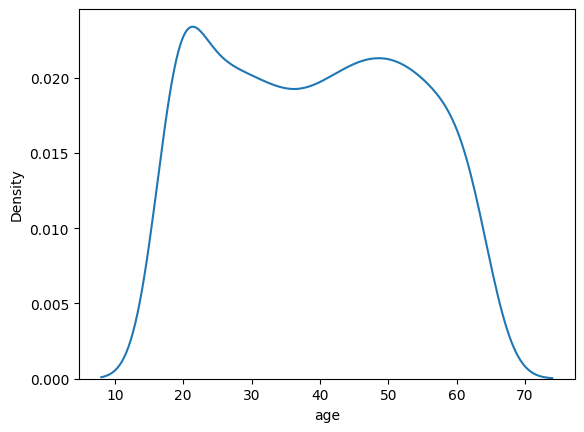

In [ ]:
# Univariate analysis of column age
import seaborn as sns
import matplotlib.pyplot as plt
sns.kdeplot(df['age'])
plt.show()

* Majority datapoins falls near age 20 and 50

In [ ]:
# Univariate Analysis of column sex
df['sex'].nunique()

2

In [ ]:
df['sex'].unique()

array(['female', 'male'], dtype=object)

In [ ]:
df['sex'].value_counts()

,count
sex,
male,675
female,662


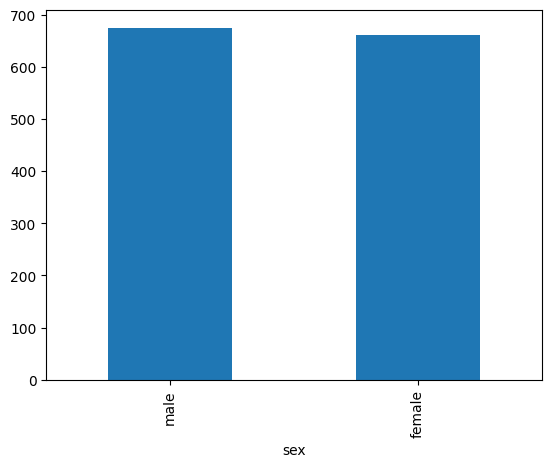

In [ ]:
df['sex'].value_counts().plot(kind='bar')
plt.show()

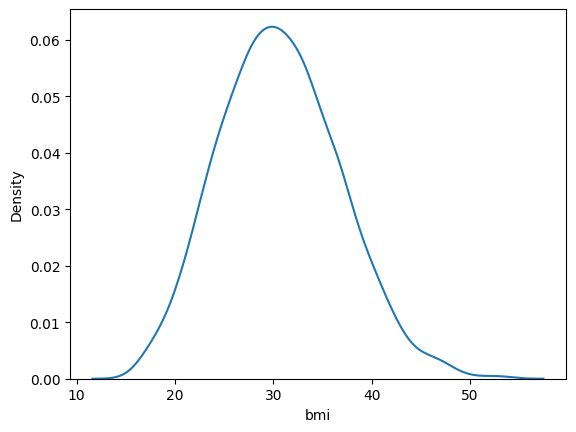

In [ ]:
# Univariate Analysis of column bmi
sns.kdeplot(df['bmi'])
plt.show()

In [ ]:
df['bmi'].mode()

,bmi
0,32.3


In [ ]:
df['bmi'].mean()

30.66345175766642

In [ ]:
# Univariate Analysis of column children
df['children'].nunique()

6

In [ ]:
df['children'].unique()

array([0, 1, 3, 2, 5, 4])

In [ ]:
df['children'].value_counts()

,count
children,
0,573
1,324
2,240
3,157
4,25
5,18


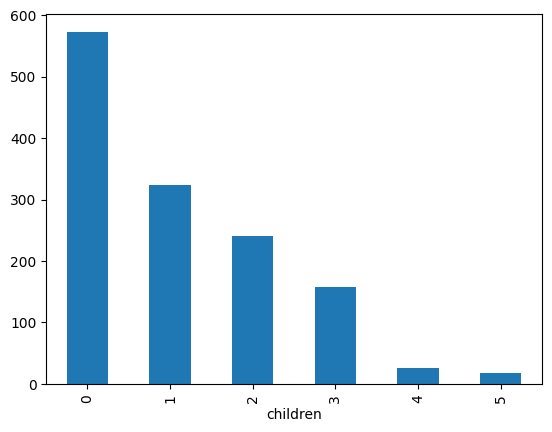

In [ ]:
df['children'].value_counts().plot(kind='bar')
plt.show()

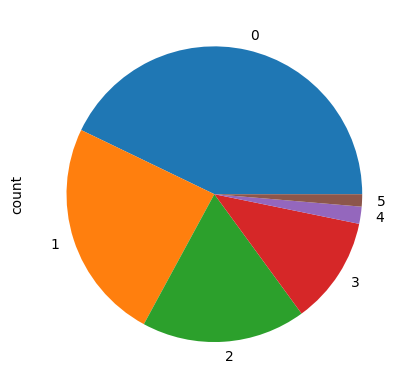

In [ ]:
df['children'].value_counts().plot(kind='pie')
plt.show()

In [ ]:
# Univariate Analysis of column smoker
df['smoker'].nunique()

2

In [ ]:
df['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [ ]:
df['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


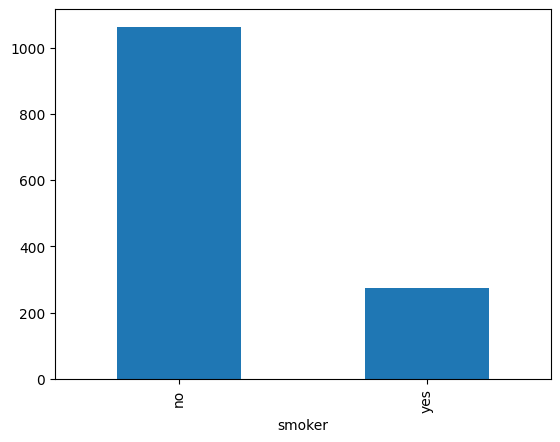

In [ ]:
df['smoker'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
# Univariate Analysis of column region
df['region'].nunique()

4

In [ ]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [ ]:
df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


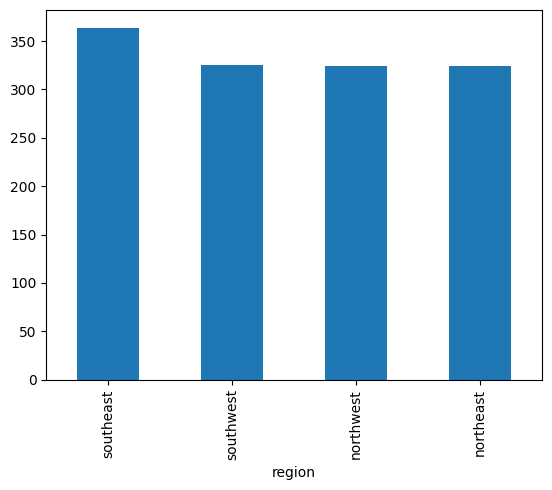

In [ ]:
df['region'].value_counts().plot(kind='bar')
plt.show()

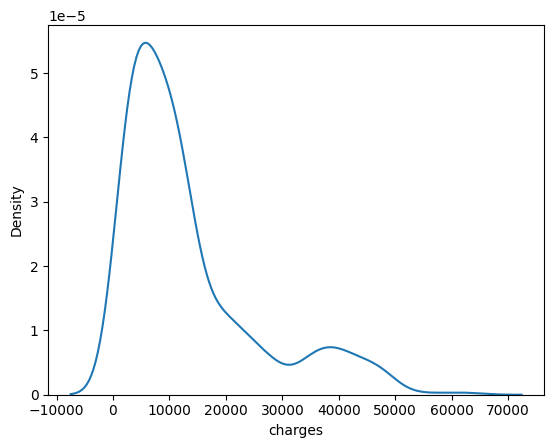

In [ ]:
# Univariate Analysis of the column charges

sns.kdeplot(df['charges'])
plt.show()

### Bivariate Analysis

In [ ]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830
1333,18,female,31.920,0,no,northeast,2205.98080
1334,18,female,36.850,0,no,southeast,1629.83350
1335,21,female,25.800,0,no,southwest,2007.94500


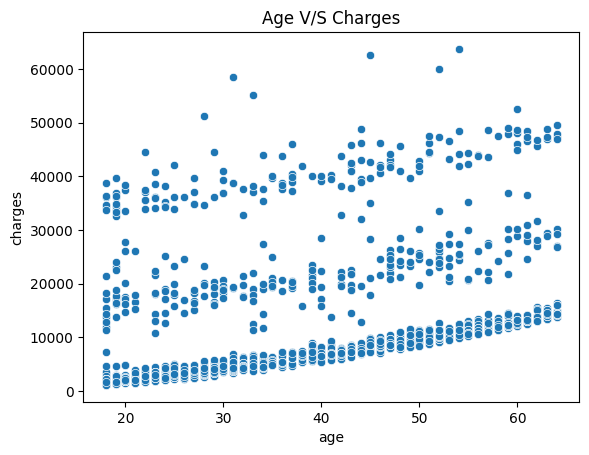

In [ ]:
# Bivariate Anlaysis  of the columns age and charges
sns.scatterplot(data=df,x='age',y='charges')
plt.title("Age V/S Charges")
plt.show()


In [ ]:
# Correlation between the column age and charges
df['charges'].corr(df['age'])

0.2983082125097864

* Column age and charges having a weak positive correlation with pearson correlation coefficient of 0.29

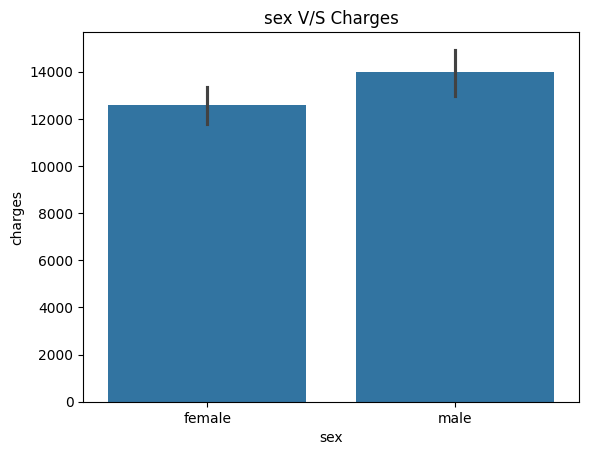

In [ ]:
# Bivariate Anlaysis  of the columns sex and charges
sns.barplot(data=df,x='sex',y='charges')
plt.title("sex V/S Charges")
plt.show()

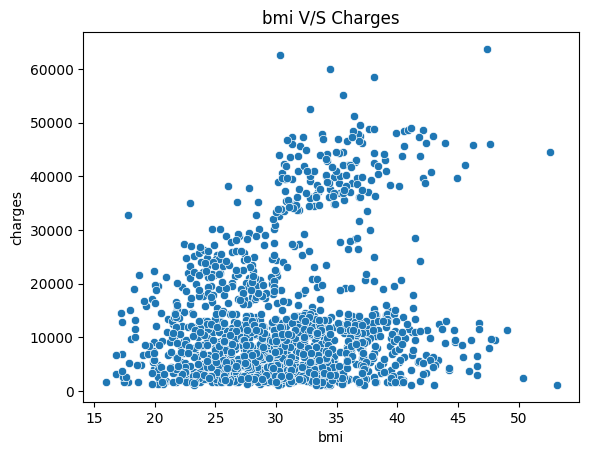

In [ ]:
# Bivariate Anlaysis  of the columns bmi and charges
sns.scatterplot(data=df,x='bmi',y='charges')
plt.title("bmi V/S Charges")
plt.show()

In [ ]:
# Correlation between the column age and charges
df['charges'].corr(df['bmi'])

0.1984008312262494

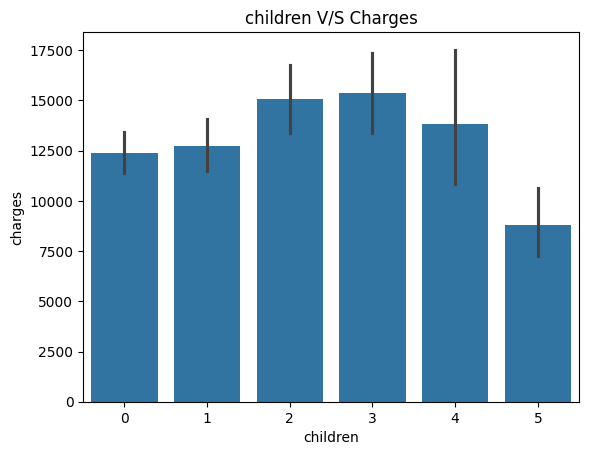

In [ ]:
# Bivariate Anlaysis  of the columns children and charges
sns.barplot(data=df,x='children',y='charges')
plt.title("children V/S Charges")
plt.show()

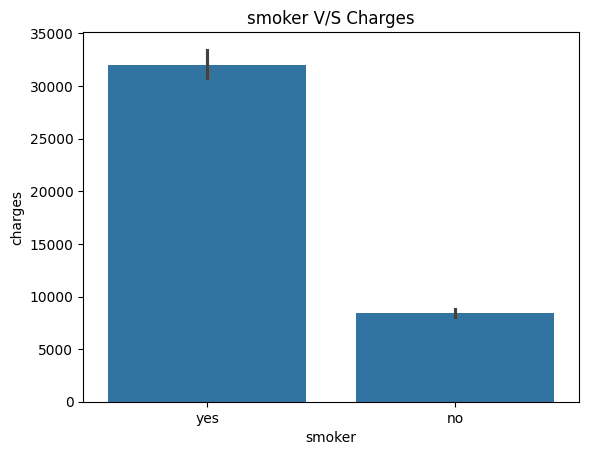

In [ ]:
# Bivariate Anlaysis  of the columns smoker and charges
sns.barplot(data=df,x='smoker',y='charges')
plt.title("smoker V/S Charges")
plt.show()

* Smokers category is having the highest charges

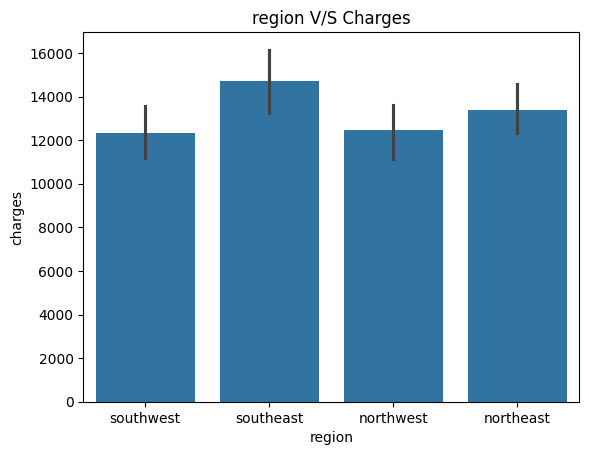

In [ ]:
# Bivariate Anlaysis  of the columns region and charges
sns.barplot(data=df,x='region',y='charges')
plt.title("region V/S Charges")
plt.show()

### Mulitvariate Analysis

In [ ]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830
1333,18,female,31.920,0,no,northeast,2205.98080
1334,18,female,36.850,0,no,southeast,1629.83350
1335,21,female,25.800,0,no,southwest,2007.94500


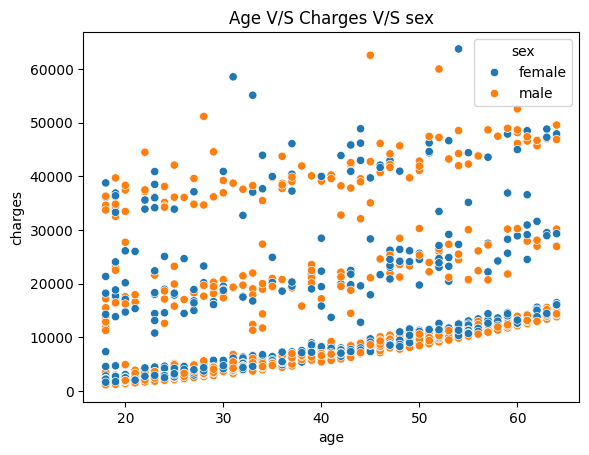

In [ ]:
# Multivariate Anlaysis  of the columns age and charges
sns.scatterplot(data=df,x='age',y='charges',hue='sex')
plt.title("Age V/S Charges V/S sex")
plt.show()

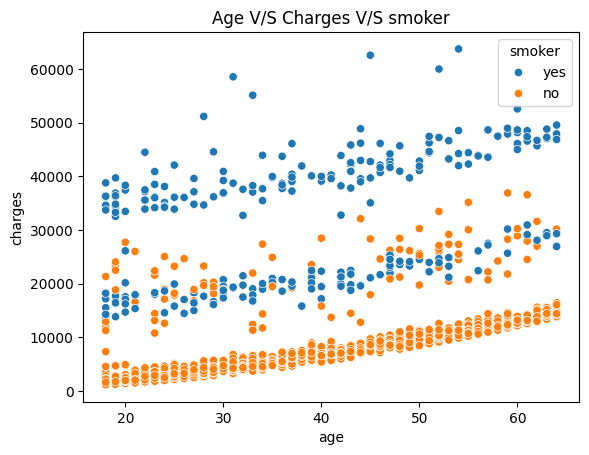

In [ ]:
# Multivariate Anlaysis  of the columns age and charges and smoker
sns.scatterplot(data=df,x='age',y='charges',hue='smoker')
plt.title("Age V/S Charges V/S smoker")
plt.show()

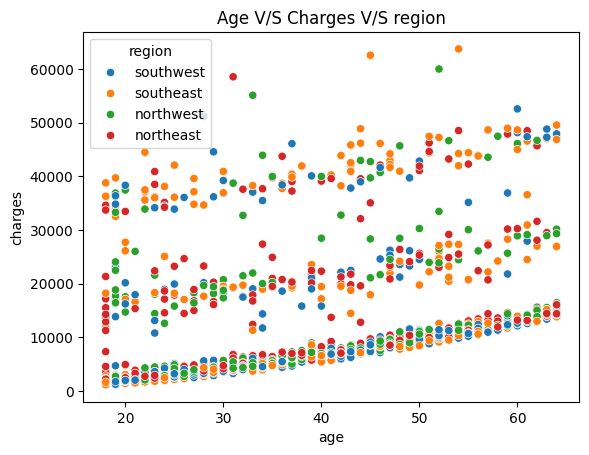

In [ ]:
# Multivariate Anlaysis  of the columns age and charges and region
sns.scatterplot(data=df,x='age',y='charges',hue='region')
plt.title("Age V/S Charges V/S region")
plt.show()

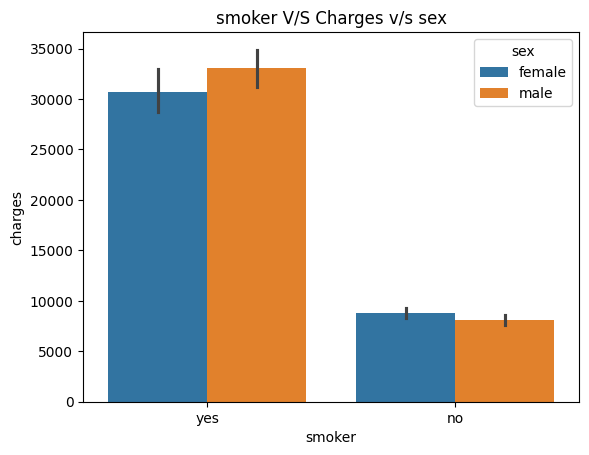

In [ ]:
# Multivariate Anlaysis  of the columns smoker and charges sex
sns.barplot(data=df,x='smoker',y='charges',hue="sex")
plt.title("smoker V/S Charges v/s sex")
plt.show()

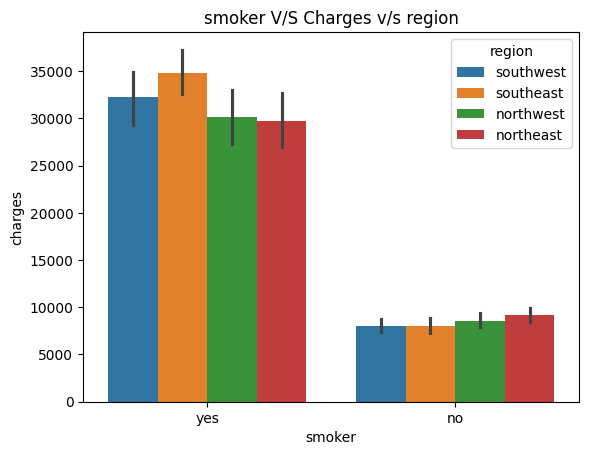

In [ ]:
# Multivariate Anlaysis of the columns smoker and charges region
sns.barplot(data=df,x='smoker',y='charges',hue="region")
plt.title("smoker V/S Charges v/s region")
plt.show()

### Feature Engineering
* Data Encoding
* Data Scaling
* Feature Extraction
* Checking for Correlation
* Checking for Multicollinearity
* Feature Removal
* Handling outliers

In [ ]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830
1333,18,female,31.920,0,no,northeast,2205.98080
1334,18,female,36.850,0,no,southeast,1629.83350
1335,21,female,25.800,0,no,southwest,2007.94500


### Data Encoding - Converting categorical columns into numerical columns
* Label Encoder
* OneHot Encoder

In [ ]:
# importing required library for data encoding
from sklearn.preprocessing import LabelEncoder

In [ ]:
lb_sex = LabelEncoder()
lb_smoker = LabelEncoder()
df['sex'] = lb_sex.fit_transform(df['sex'])
df['smoker'] = lb_smoker.fit_transform(df['smoker'])
# sex : female - 0 , Male - 1
# smoker : yes - 1 , no - 0
df['region'] = df['region'].replace({'southwest':0,'southeast':1,'northwest':0,'northeast':1})

<ipython-input-77-002df67a6988>:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['region'] = df['region'].replace({'southwest':0,'southeast':1,'northwest':0,'northeast':1})


In [ ]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,0,16884.92400
1,18,1,33.770,1,0,1,1725.55230
2,28,1,33.000,3,0,1,4449.46200
3,33,1,22.705,0,0,0,21984.47061
4,32,1,28.880,0,0,0,3866.85520
...,...,...,...,...,...,...,...
1332,50,1,30.970,3,0,0,10600.54830
1333,18,0,31.920,0,0,1,2205.98080
1334,18,0,36.850,0,0,1,1629.83350
1335,21,0,25.800,0,0,0,2007.94500


In [ ]:
df.dtypes

,0
age,int64
sex,int64
bmi,float64
children,int64
smoker,int64
region,int64
charges,float64


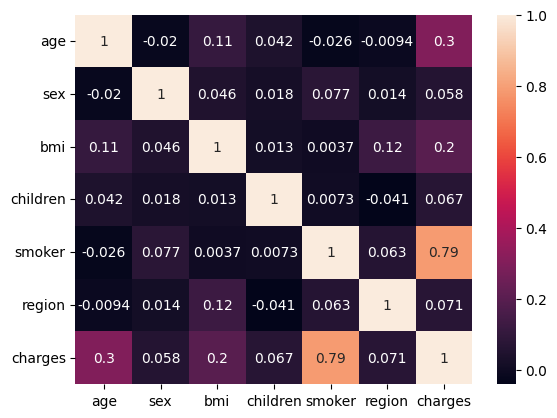

In [ ]:
# Checking for Correlaion
sns.heatmap(df.corr(),annot=True)
plt.show()

In [ ]:
best_columns = ["age","bmi","smoker","charges"]
df_new = df[best_columns]
df_new

,age,bmi,smoker,charges
0,19,27.900,1,16884.92400
1,18,33.770,0,1725.55230
2,28,33.000,0,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1332,50,30.970,0,10600.54830
1333,18,31.920,0,2205.98080
1334,18,36.850,0,1629.83350
1335,21,25.800,0,2007.94500


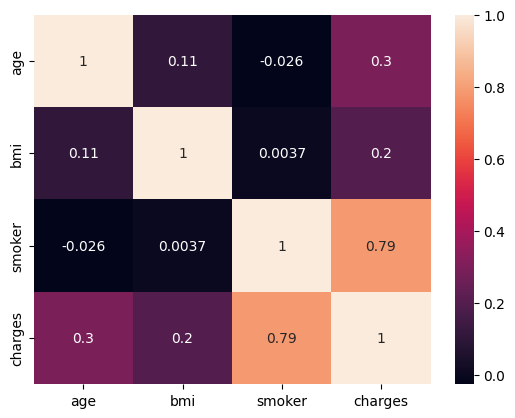

In [ ]:
# Checking for Multicollinearity
sns.heatmap(df_new.corr(),annot=True)
plt.show()

# Handling Outliers

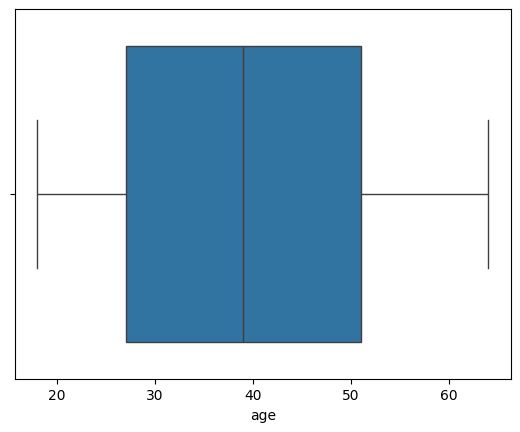

In [ ]:
sns.boxplot(df['age'],orient='h')
plt.show()

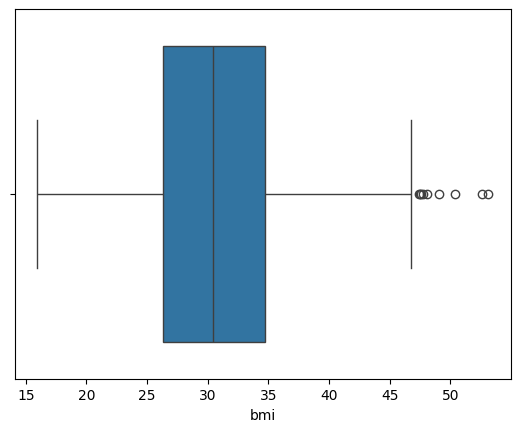

In [ ]:
sns.boxplot(df['bmi'],orient='h')
plt.show()

In [ ]:
q1=np.quantile(df['bmi'],0.25)
q3=np.quantile(df['bmi'],0.75)
IQR=q3-q1
minimum=q1-1.5*IQR
Maximum=q3+1.5*IQR
for i in range(len(df['bmi'])):
    if df['bmi'][i]>Maximum:
        df['bmi'][i]=Maximum
    elif df['bmi'][i]<minimum:
        df['bmi'][i]=minimum
    else:
        pass

<ipython-input-85-14110cd3b44d>:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['bmi'][i]=Maximum
<ipython-input-85-14110cd3b44d>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the cave

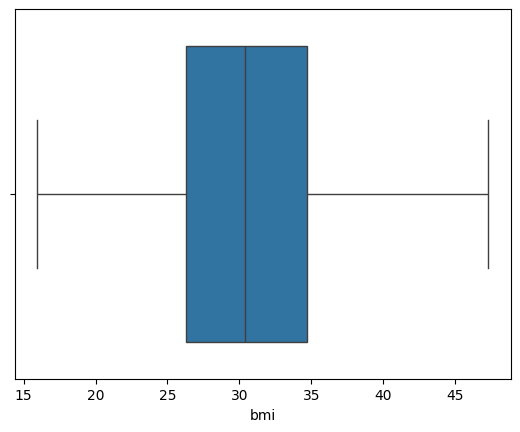

In [ ]:
sns.boxplot(df['bmi'],orient='h')
plt.show()

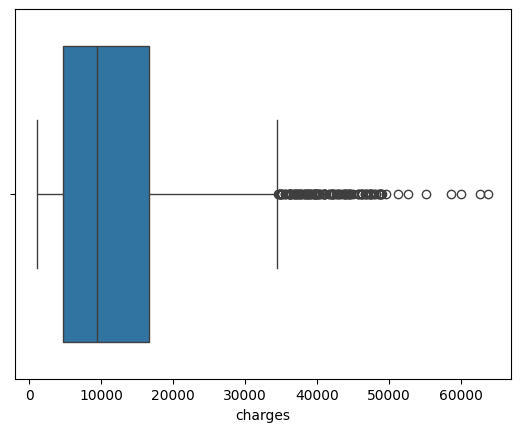

In [ ]:
sns.boxplot(df['charges'],orient='h')
plt.show()

In [ ]:
q1=np.quantile(df['charges'],0.25)
q3=np.quantile(df['charges'],0.75)
IQR=q3-q1
minimum=q1-1.5*IQR
Maximum=q3+1.5*IQR
for i in range(len(df['charges'])):
    if df['charges'][i]>Maximum:
        df['charges'][i]=Maximum
    elif df['charges'][i]<minimum:
        df['charges'][i]=minimum
    else:
        pass

<ipython-input-88-83d8d57fdae2>:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['charges'][i]=Maximum
<ipython-input-88-83d8d57fdae2>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the 

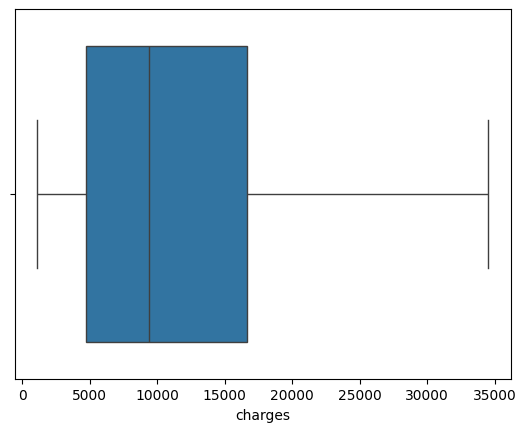

In [ ]:
sns.boxplot(df['charges'],orient='h')
plt.show()

# Data Scaling
 *Normalization (0-1)
 *Standardization (-3,+3)


In [ ]:
df_new

,age,bmi,smoker,charges
0,19,27.900,1,16884.92400
1,18,33.770,0,1725.55230
2,28,33.000,0,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1332,50,30.970,0,10600.54830
1333,18,31.920,0,2205.98080
1334,18,36.850,0,1629.83350
1335,21,25.800,0,2007.94500


In [ ]:
from sklearn.preprocessing import StandardScaler


In [ ]:

std_age = StandardScaler()
std_bmi = StandardScaler()
df_new['age'] = std_age.fit_transform(df_new[['age']])
df_new['bmi'] = std_bmi.fit_transform(df_new[['bmi']])

<ipython-input-92-694d87822ab1>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['age'] = std_age.fit_transform(df_new[['age']])
<ipython-input-92-694d87822ab1>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['bmi'] = std_bmi.fit_transform(df_new[['bmi']])


In [ ]:
df_new

,age,bmi,smoker,charges
0,-1.440418,-0.453160,1,16884.92400
1,-1.511647,0.509422,0,1725.55230
2,-0.799350,0.383155,0,4449.46200
3,-0.443201,-1.305052,0,21984.47061
4,-0.514431,-0.292456,0,3866.85520
...,...,...,...,...
1332,0.767704,0.050269,0,10600.54830
1333,-1.511647,0.206053,0,2205.98080
1334,-1.511647,1.014490,0,1629.83350
1335,-1.297958,-0.797524,0,2007.94500


## Model Building

In [ ]:
df_new

,age,bmi,smoker,charges
0,-1.440418,-0.453160,1,16884.92400
1,-1.511647,0.509422,0,1725.55230
2,-0.799350,0.383155,0,4449.46200
3,-0.443201,-1.305052,0,21984.47061
4,-0.514431,-0.292456,0,3866.85520
...,...,...,...,...
1332,0.767704,0.050269,0,10600.54830
1333,-1.511647,0.206053,0,2205.98080
1334,-1.511647,1.014490,0,1629.83350
1335,-1.297958,-0.797524,0,2007.94500


In [ ]:
# splitting the dataset into input features and target varibles

x = df_new.drop('charges',axis=1)
y = df_new['charges']

In [ ]:
x

,age,bmi,smoker
0,-1.440418,-0.453160,1
1,-1.511647,0.509422,0
2,-0.799350,0.383155,0
3,-0.443201,-1.305052,0
4,-0.514431,-0.292456,0
...,...,...,...
1332,0.767704,0.050269,0
1333,-1.511647,0.206053,0
1334,-1.511647,1.014490,0
1335,-1.297958,-0.797524,0


In [ ]:
y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1332,10600.54830
1333,2205.98080
1334,1629.83350
1335,2007.94500


In [ ]:
# splitting into train and test data
# train data - 80%
# test data - 20%

# from sklearn.model_selection import train_test_split
# from sklearn.neighbors import KNeighborsRegressor
# from sklearn.preprocessing import PolynomialFeatures
# from sklearn.metrics import accuracy_score,r2_score,mean_squared_error,mean_absolute_error


x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train

,age,bmi,smoker
1113,-1.155499,-1.009063,0
967,-1.297958,-0.806543,0
598,0.910164,1.125178,0
170,1.693691,1.772092,0
275,0.554015,-0.666338,0
...,...,...,...
1095,0.838934,0.704562,1
1130,-0.870580,2.498538,0
1294,-1.369188,-1.420660,0
860,-0.087053,-0.436761,0


In [ ]:
y_train

,charges
1113,2396.09590
967,3279.86855
598,33471.97189
170,13405.39030
275,9715.84100
...,...
1095,44641.19740
1130,3693.42800
1294,1964.78000
860,7151.09200


In [ ]:
x_test

,age,bmi,smoker
899,0.696474,-1.336209,0
1063,-0.728120,-0.830321,0
1255,0.838934,0.938238,0
298,-0.585661,0.611091,1
237,-0.585661,1.267024,0
...,...,...,...
534,1.764921,1.609749,0
542,1.693691,0.924299,0
759,-1.226729,0.642248,0
1283,1.551231,0.924299,1


In [ ]:
# creating the object the class KNeighborRegressor
#from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=7)

In [ ]:
# Training the model
knn.fit(x_train,y_train)

KNeighborsRegressor(n_neighbors=7)

In [ ]:
y_predknn = knn.predict(x_test)
y_predknn

array([ 9075.26194286,  3960.38201429, 11926.26395286, 38258.32861   ,
        6602.61426714, 11900.25132286, 38704.64791286,  5357.93166286,
        9772.44479143, 13008.48854143, 13204.91907857, 24359.25288571,
       37629.29862857, 14058.06729143,  5431.60867857, 12135.13903857,
        8490.25275   , 39300.32371429,  3129.96341429,  6192.42617857,
        8490.25275   , 20516.10665714,  9284.46754286, 22641.22619857,
       38972.27465286,  9544.10331143, 43627.75748714, 45688.29637857,
        9262.61099286, 11122.09474857,  4678.05045714,  9352.51447143,
        1854.27195   , 12918.39782143, 26518.06968571,  9957.66609286,
        3303.88839857,  3907.72012143, 24018.15130714, 11072.56678857,
        2476.17404286, 20914.77329571, 41453.02044286, 13022.33217286,
        8183.63382857,  3972.4118    ,  3556.06885   , 11218.75707429,
        3972.4118    ,  7059.80845   ,  5948.30275714,  9437.00964143,
       23714.71969571,  8190.95795714,  9567.78157   , 11566.62211   ,
      

In [ ]:
accuracy = knn.score(x_test,y_test)
accuracy

0.8411426409338252

In [ ]:
r2_score(y_test,y_predknn)

0.8411426409338252

In [ ]:
mean_squared_error(y_test,y_predknn)

29191003.04596395

In [ ]:
mean_absolute_error(y_test,y_predknn)

2930.086953477079

In [ ]:
df_new

,age,bmi,smoker,charges
0,-1.440418,-0.453160,1,16884.92400
1,-1.511647,0.509422,0,1725.55230
2,-0.799350,0.383155,0,4449.46200
3,-0.443201,-1.305052,0,21984.47061
4,-0.514431,-0.292456,0,3866.85520
...,...,...,...,...
1332,0.767704,0.050269,0,10600.54830
1333,-1.511647,0.206053,0,2205.98080
1334,-1.511647,1.014490,0,1629.83350
1335,-1.297958,-0.797524,0,2007.94500


In [ ]:
knn.predict([[0.767704,0.0502692,0]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


array([11465.12192286])

In [ ]:
knn.predict([[-1.511647,1.014490,0]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


array([2315.98691429])

In [ ]:
 from sklearn.tree import DecisionTreeRegressor

In [ ]:
decision_tree=DecisionTreeRegressor()

In [ ]:
# Training the model
decision_tree.fit(x_train,y_train)

DecisionTreeRegressor()

In [ ]:
y_pred_decision = decision_tree.predict(x_test)
y_pred_decision

array([10156.7832  ,  3353.284   , 10848.1343  , 36837.467   ,
        4667.60765 ,  8125.7845  , 37484.4493  ,  2709.1119  ,
       19144.57652 ,  8703.456   , 12957.118   , 24520.264   ,
       37079.372   , 14235.072   ,  6196.448   ,  8516.829   ,
        1748.774   , 37742.5757  ,  2352.96845 , 24671.66334 ,
        1748.774   , 20234.85475 ,  9541.69555 , 20234.85475 ,
       36950.2567  , 26018.95052 , 43753.33705 , 45008.9555  ,
        8116.68    , 26392.26029 ,  5425.02335 ,  8125.7845  ,
        1121.8739  , 12233.828   , 48549.17835 ,  9283.562   ,
        1253.936   ,  4906.40965 , 22412.6485  ,  8823.279   ,
        1633.9618  , 18767.7377  , 41034.2214  ,  9630.397   ,
        7526.70645 ,  5312.16985 ,  1634.5734  ,  6849.026   ,
        5312.16985 ,  6238.298   ,  4449.462   ,  5662.225   ,
       21880.82    ,  1880.487   ,  7160.3303  ,  8413.46305 ,
       19749.38338 ,  3176.8159  , 36950.2567  ,  9222.4026  ,
        9541.69555 ,  5584.3057  , 11488.31695 ,  2304.

In [ ]:
accuracy =decision_tree.score(x_test,y_test)
accuracy

0.7926126835701742

In [ ]:
r2_score(y_test,y_pred_decision)

0.7926126835701742

In [ ]:
mean_squared_error(y_test,y_pred_decision)

38108676.9991908

In [ ]:
mean_absolute_error(y_test,y_pred_decision)

3095.0663444552238

In [ ]:
df_new

,age,bmi,smoker,charges
0,-1.440418,-0.453160,1,16884.92400
1,-1.511647,0.509422,0,1725.55230
2,-0.799350,0.383155,0,4449.46200
3,-0.443201,-1.305052,0,21984.47061
4,-0.514431,-0.292456,0,3866.85520
...,...,...,...,...
1332,0.767704,0.050269,0,10600.54830
1333,-1.511647,0.206053,0,2205.98080
1334,-1.511647,1.014490,0,1629.83350
1335,-1.297958,-0.797524,0,2007.94500


In [ ]:
decision_tree.predict([[-1.511647,0.206053,0]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([2205.9808])

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
linear_=LinearRegression()

In [ ]:
# Training the model
linear_.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred_linear = linear_.predict(x_test)
y_pred_linear

array([ 8433.67443577,  4336.46678013, 13165.0382606 , 30593.69534864,
        8738.64384303, 13004.1887831 , 29273.63576136,  2177.09021482,
       10922.95093736, 10315.83022735, 11021.84491859, 33740.33309282,
       30613.92158231, 18004.87150727,  9656.23179762,  9311.37354392,
        4325.12010919, 32099.96630635,  3001.71338943,  5552.62898392,
        4325.12010919, 29913.00795743, 14580.01800456, 30752.45719245,
       31444.92261851,  4769.02189756, 35187.05259131, 37413.46842278,
       10952.8675722 , 12177.75978526,  6505.9651105 , 13121.95183512,
         870.87899962, 12471.87695664, 40355.37672202, 12499.04467281,
        2732.11267963,  2866.20850841, 32023.18474965,  9365.1280589 ,
        6903.0538664 , 29243.81679061, 34097.79751626, 11919.91981386,
        6896.22734444,  4145.55111435,  6040.33037213,  9173.38425823,
        4186.69945959,  8909.59778913,  6340.1295272 , 12053.6361681 ,
       30836.41015271,  4425.70495311, 10719.84316929,  9666.05445578,
      

In [ ]:
accuaracy=linear_.score(x_test,y_test)
accuaracy

0.8049502474643171

In [ ]:
r2_score(y_test,y_pred_linear)

0.8049502474643171

In [ ]:
mean_squared_error(y_test,y_pred_linear)

35841574.81814753

In [ ]:
mean_absolute_error(y_test,y_pred_linear)

4191.704294603893

### Model Building using RandomForest Regressor (Bagging Method)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
random_forest=RandomForestRegressor()

In [ ]:
# Training the model
random_forest.fit(x_train,y_train)

RandomForestRegressor()

In [ ]:
y_pred_random = random_forest.predict(x_test)
y_pred_random

array([ 9712.5349413 ,  3914.2890895 ,  9458.553993  , 41113.5205959 ,
        6209.9962452 , 10576.3530388 , 38370.3114933 ,  4388.2495584 ,
       14629.8859966 ,  9155.3410474 , 13644.25414197, 24508.0938335 ,
       41233.5476202 , 15465.9372612 ,  6733.0427823 ,  8972.8102914 ,
        7604.5740692 , 39291.4660932 ,  3551.8442632 , 16758.4237353 ,
        7604.5740692 , 20497.7489945 ,  9947.3741666 , 21923.7653616 ,
       41424.4598581 ,  7990.8403592 , 42644.5001035 , 45489.6261065 ,
        9208.1595421 , 15767.2881334 ,  5310.9046891 ,  9212.9850275 ,
        1715.8043385 , 12851.3338137 , 47983.3786135 ,  9478.727152  ,
        1580.15197   ,  4380.818296  , 23308.5579319 , 10403.0919483 ,
        2413.9385945 , 20043.79333881, 41103.2652737 , 10068.7921826 ,
        8013.6920936 ,  4535.0182845 ,  1864.298008  , 10232.4496847 ,
        4352.0563185 ,  7399.29365604,  4037.1551125 ,  7094.2002189 ,
       21984.4249835 ,  4425.9890248 ,  7274.4379747 ,  9224.3195665 ,
      

In [ ]:
accuracy =random_forest.score(x_test,y_test)
accuracy

0.8798666748907771

In [ ]:
r2_score(y_test,y_pred_random)

0.8798666748907771

In [ ]:
mean_squared_error(y_test,y_pred_random)

22075226.982240573

In [ ]:
mean_absolute_error(y_test,y_pred_random)

2647.338851499488

### Model Building using AdaBoost Regressor (Boosting Method)


In [ ]:
from sklearn.ensemble import AdaBoostRegressor

In [ ]:
Ada=AdaBoostRegressor()

In [ ]:
# Training the model
Ada.fit(x_train,y_train)

AdaBoostRegressor()

In [ ]:
y_pred_ada =Ada.predict(x_test)
y_pred_ada

array([13327.59698522,  6668.82198259, 13327.59698522, 44217.64076986,
        9165.43582264, 13327.59698522, 37880.72333725,  6668.82198259,
       10462.12153803, 13327.59698522, 18218.20486794, 25557.12062096,
       44217.64076986, 13327.59698522,  9165.43582264, 10462.12153803,
        9165.43582264, 44217.64076986,  6668.82198259,  6668.82198259,
        9165.43582264, 18773.4938678 , 13327.59698522, 18773.4938678 ,
       44217.64076986,  9165.43582264, 44217.64076986, 46017.66923435,
       13327.59698522, 13327.59698522,  6668.82198259, 13327.59698522,
        4620.21102055, 18218.20486794, 46017.66923435, 13327.59698522,
        6668.82198259,  5370.37402556, 25226.07855405, 10462.12153803,
        9165.43582264, 25226.07855405, 44217.64076986, 13327.59698522,
       10462.12153803,  6668.82198259,  4620.21102055, 10462.12153803,
        6668.82198259,  9165.43582264,  9165.43582264,  9165.43582264,
       25226.07855405,  9165.43582264,  9165.43582264, 10462.12153803,
      

In [ ]:
accuracy =Ada.score(x_test,y_test)
accuracy

0.8694892239768062

In [ ]:
r2_score(y_test,y_pred_ada)

0.8694892239768062

In [ ]:
mean_squared_error(y_test,y_pred_ada)

23982146.51697157

In [ ]:
mean_absolute_error(y_test,y_pred_ada)

3833.686164772809

## MODEL VALIDATION OF LINEAR REGRESSSION
* MEAN SQUARED ERROR(MSE)
* ROOT MEAN SQUARED ERROR(RMSE)
* MEAN ABSOLUTE ERROR(MAE)
* R-SQUERED(R^2)

In [ ]:
# r2_score
r2_score(y_test,y_pred_ada)

0.8694892239768062

In [ ]:
#,mean_squared_error
mean_squared_error(y_test,y_pred_ada)

23982146.51697157

In [ ]:
# mean_absolute_error
mean_absolute_error(y_test,y_pred_ada)

3833.686164772809

In [ ]:
def insurance_predictor(age,bmi,smoker):
    age_scale = std_age.transform([[age]])[0,0]
    bmi_scale = std_bmi.transform([[bmi]])[0,0]
    price = knn.predict([[age_scale,bmi_scale,smoker]])
    return price

age = int(input('Enter Your Age : '))
bmi = int(input("Enter Your BMI : "))
smoker = int(input("Are You a Smoker :\n0. No \n1. Yes\n"))
insurance_price = insurance_predictor(age,bmi,smoker)[0]
print(f"Your Insurance Price : {insurance_price}")

Enter Your Age : 22
Enter Your BMI : 67567
Are You a Smoker :
0. No 
1. Yes
1
Your Insurance Price : 12693.641842857145


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
